# Librerías

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.manifold import TSNE
import numpy as np
from kmodes.kmodes import KModes

from sklearn.metrics import silhouette_score

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Lectura de datos

In [3]:
df = pd.read_parquet('../data/EMCALI/datos_procesados/consumo_011223_01062025_filtrado.parquet')
inspecciones = pd.read_csv('../data/EMCALI/datos_procesados/info_inspecciones.csv')
predicciones = pd.read_csv('../data/Resultados/supervisado_predicciones_completo.csv')
categorias_anomalias = pd.read_excel('../data/EMCALI/categorias_anomalias.xlsx')
df = df[df.producto.isin(inspecciones.producto)]

In [4]:
categorias_anomalias = categorias_anomalias[(categorias_anomalias[
    'alteracion por parte de usuario'] == 'Sí') & 
    (categorias_anomalias["facturación mayor a lo esperado"] == 'No')].Categoría

inspecciones = inspecciones[
    (inspecciones.anomalia.isin(categorias_anomalias) & inspecciones.anomalo == 1) | (inspecciones.anomalo == 0)]

In [5]:
df.head()

,producto,ano,mes,consumo,localidad,barrio,tipo_producto,categoria,subcategoria,fecha,CLIENTE_ID
3781,1187,2023,12,46.0,76001.0,101.0,6140.0,1.0,2.0,2023-12-01,1187
3782,1187,2024,1,71.0,76001.0,101.0,6140.0,1.0,2.0,2024-01-01,1187
3783,1187,2024,2,47.0,76001.0,101.0,6140.0,1.0,2.0,2024-02-01,1187
3784,1187,2024,3,51.0,76001.0,101.0,6140.0,1.0,2.0,2024-03-01,1187
3785,1187,2024,4,64.0,76001.0,101.0,6140.0,1.0,2.0,2024-04-01,1187


# Procesamiento de datos

In [6]:
df = df.merge(inspecciones[['producto', 'anomalo']], on = 'producto')

In [7]:
df.head()

,producto,ano,mes,consumo,localidad,barrio,tipo_producto,categoria,subcategoria,fecha,CLIENTE_ID,anomalo
0,1187,2023,12,46.0,76001.0,101.0,6140.0,1.0,2.0,2023-12-01,1187,1.0
1,1187,2024,1,71.0,76001.0,101.0,6140.0,1.0,2.0,2024-01-01,1187,1.0
2,1187,2024,2,47.0,76001.0,101.0,6140.0,1.0,2.0,2024-02-01,1187,1.0
3,1187,2024,3,51.0,76001.0,101.0,6140.0,1.0,2.0,2024-03-01,1187,1.0
4,1187,2024,4,64.0,76001.0,101.0,6140.0,1.0,2.0,2024-04-01,1187,1.0


In [8]:
df_grouped = df.groupby(['producto', 'localidad', 'barrio', 
                         'tipo_producto', 'categoria','subcategoria','anomalo']).agg(
                             {'consumo': 'mean'}).reset_index()
df_grouped.set_index('producto', inplace=True)
df_grouped.head()

,localidad,barrio,tipo_producto,categoria,subcategoria,anomalo,consumo
producto,,,,,,,
1187,76001.0,101.0,6140.0,1.0,2.0,1.0,53.105263
2212,76001.0,101.0,6140.0,1.0,2.0,1.0,215.315789
2331,76001.0,101.0,6140.0,1.0,2.0,0.0,165.631579
3134,76001.0,101.0,6140.0,1.0,2.0,1.0,158.842105
5802,76001.0,196.0,6140.0,1.0,1.0,0.0,183.000000


In [9]:
df_grouped.groupby('anomalo').agg({'consumo': ['mean', 'median']})

consumo            
               mean      median
anomalo                        
0.0      562.026817  193.789474
1.0      372.835705  157.890351

In [10]:
df_grouped.dropna(inplace = True)

# Clustering
- KModes
- Costo: Cuenta cuántos atributos diferentes hay entre cada punto y su centroide, sumando todo
$$\text{Cost} = \sum_{k=1}^{K} \sum_{x_i \in C_k} \sum_{j=1}^{m} \delta(x_{ij}, c_{kj})$$
$$\delta(x_{ij}, c_{kj}) = \begin{cases} 
0 & \text{si } x_{ij} = c_{kj} \\
1 & \text{si } x_{ij} \neq c_{kj}
\end{cases}$$
- Donde: 
    - K = número de clusters
    - Ck​ = conjunto de puntos en el cluster k
    - xi​ = punto de datos ii
    - xij​ = valor del atributo j para el punto i
    - ck​ = centroide del cluster k
    - ckj​ = valor del atributo j en el centroide k
    - m = número de atributos categóricos

(7629, 5)

Calculando elbow...
K=5: costo=9124
K=6: costo=8208
K=7: costo=8270
K=8: costo=7986
K=9: costo=7537
K=10: costo=7180
K=11: costo=7171
K=12: costo=7126
K=13: costo=7109
K=14: costo=7007
K=15: costo=6970
K=16: costo=6949
K=17: costo=6900
K=18: costo=6851
K=19: costo=6813
K=20: costo=6804


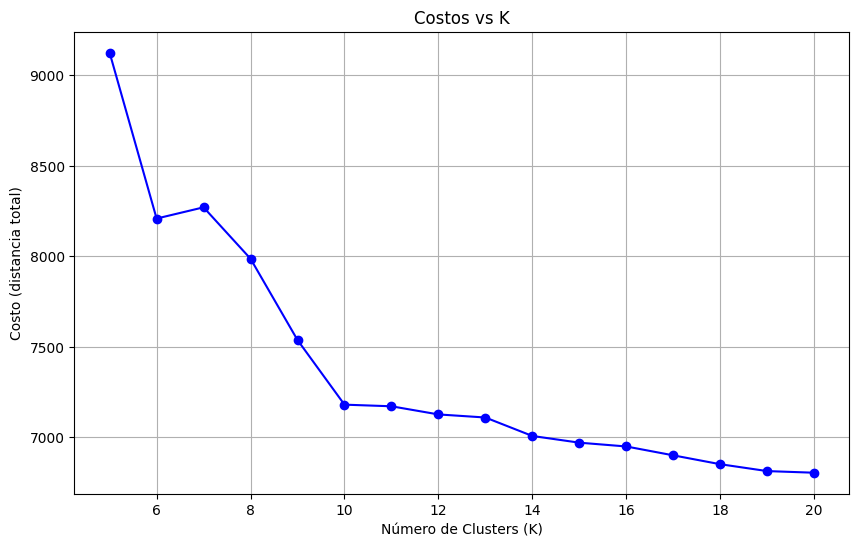

In [11]:
X = df_grouped.drop(columns = ['anomalo', 'consumo']).copy()
X = X.dropna()
print(X.shape)

X_scaled = X

costos = []
K_range = range(5, 21)  # Prueba K de 5 a 20

print("\nCalculando elbow...")
for k in K_range:
    km =  KModes(
        n_clusters=k, 
        init='Cao',          # Mejor inicialización que 'Huang'
        n_init=20,           # Más intentos (era 5, ahora 20)
        max_iter=150,        # Más iteraciones
        verbose=0, 
        random_state=42
    )
    km.fit(X_scaled)
    costos.append(km.cost_)  # Similar a inercia en K-means
    print(f"K={k}: costo={km.cost_:.0f}")

# Grafica el Elbow
plt.figure(figsize=(10, 6))
plt.plot(K_range, costos, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Costo (distancia total)')
plt.title('Costos vs K')
plt.grid(True)
plt.show()

In [12]:
k = 10
kmodes = KModes(
        n_clusters=k, 
        init='Cao',
        n_init=20,    
        max_iter=100,      
        verbose=0, 
        random_state=42
    )
clusters = kmodes.fit_predict(X_scaled)
df_grouped['cluster'] = clusters

In [13]:
info_clusters =  pd.DataFrame(columns = ['cluster', 'tot_datos', 'anomalos', 
                                                      'no_anomalos', 'pct_anomalos', 'pct_no_anomalos',
                                                      'mean_consumo_avg_anomalos', 'mean_consumo_avg_no_anomalos', 
                                                      'diferencia'])
for cluster_id in df_grouped['cluster'].unique():
    cluster_data = df_grouped[df_grouped['cluster'] == cluster_id]
    fraudes = cluster_data[cluster_data['anomalo']==1]
    limpios = cluster_data[cluster_data['anomalo'] == 0]

    info_clusters.loc[len(info_clusters)] = {
        'cluster': cluster_id,
        'tot_datos': len(cluster_data),
        'anomalos': len(fraudes),
        'no_anomalos': len(limpios),
        'pct_anomalos': len(fraudes)/len(cluster_data),
        'pct_no_anomalos': len(limpios)/len(cluster_data),
        'mean_consumo_avg_anomalos': fraudes['consumo'].mean(),
        'mean_consumo_avg_no_anomalos': limpios['consumo'].mean(),
        'diferencia': limpios['consumo'].median() - fraudes['consumo'].median()
    }
info_clusters[['cluster', 'tot_datos', 'pct_anomalos', 'diferencia']]

,cluster,tot_datos,pct_anomalos,diferencia
0,5,1619,0.449660,3.552632
1,0,1088,0.333640,1.526316
2,1,2537,0.152542,13.106550
3,3,59,0.237288,-2262.605272
4,8,406,0.258621,-34.052632
5,9,287,0.313589,8.510062
6,2,1388,0.342219,1.090643
7,7,108,0.101852,62.555556
8,6,136,0.095588,-42.368421
9,4,1,0.000000,NaN


In [14]:
c3_anomalo_max = df_grouped[(df_grouped.cluster == 3) & (df_grouped.anomalo == 1)].consumo.idxmax()
inspecciones[inspecciones.producto == c3_anomalo_max]

,producto,fecha_visita,anomalo,anomalia
1013,245659.0,2025-08-08 00:00:00,1.0,D_A2 - ACOMETIDA EMPALMADA


In [16]:
clusters_considerar = info_clusters[info_clusters.diferencia>0].cluster.unique()
clusters_considerar

array([5, 0, 1, 9, 2, 7], dtype=uint16)

# Predicciones
- Analizamos en diferentes umbrales cómo se ven los anómalos detectados.
- El beneficio total sería una suma sobre todos los clusters:
$$\sum_c (TP_c × kWhRecuperados_c × preciokWh) - (TP + FP) × costoVisita$$

In [17]:
df_grouped = df_grouped[df_grouped.cluster.isin(clusters_considerar)]

In [18]:
df_grouped = df_grouped.merge(predicciones[['producto','prediccion_lgbm']], on = 'producto')

In [19]:
precio_kwh = 850  # Promedio de costo de kWh 
costo_visita = 50000  # COP por visita
ganancia_futuro = 1/((1.15)**(1/12)-1)  # Meses que me demoré en darme cuenta de la anomalía -- formula 
ganancia_futuro

85.36125410375644

In [20]:
resultados = []

for threshold in np.arange(0.1, 0.95, 0.05):
    visitar = df_grouped['prediccion_lgbm'] > threshold
    
    beneficio_total = 0
    TP_total = 0
    FP_total = 0
    
    for cluster_id in clusters_considerar:
        mask_cluster = df_grouped['cluster'] == cluster_id
        
        # TP: visitaste Y era fraude Y en este cluster
        TP_mask = visitar & (df_grouped['anomalo'] == 1) & mask_cluster
        TP = TP_mask.sum()
        TP_total += TP
        
        # FP: visitaste Y NO era fraude Y en este cluster
        FP_mask = visitar & (df_grouped['anomalo'] == 0) & mask_cluster
        FP = FP_mask.sum()
        FP_total += FP
        
        # Beneficio de los TP de este cluster
        dif_cluster = info_clusters[info_clusters["cluster"] == cluster_id].iloc[0].diferencia 
        kWh_recuperados_cluster = TP * dif_cluster * ganancia_futuro 
        beneficio_cluster = kWh_recuperados_cluster * precio_kwh
        beneficio_total += beneficio_cluster
    
    n_visitas_total = TP_total + FP_total
    costo_total = n_visitas_total * costo_visita
    beneficio_neto = beneficio_total - costo_total

    FN = ((~visitar) & (df_grouped['anomalo'] == 1)).sum()
    
    precision = TP_total / n_visitas_total if n_visitas_total > 0 else 0
    recall = TP_total / (TP_total + FN) if (TP_total + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    resultados.append({
        "threshold": threshold,
        "beneficio_total": beneficio_total,
        "costo_total": costo_total,
        "beneficio_neto": beneficio_neto,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
resultados = pd.DataFrame(resultados)
resultados

,threshold,beneficio_total,costo_total,beneficio_neto,precision,recall,f1
0,0.10,7.332643e+08,336600000,3.966643e+08,0.304219,0.997079,0.466196
1,0.15,7.210386e+08,313800000,4.072386e+08,0.324729,0.992210,0.489316
2,0.20,7.070773e+08,287700000,4.193773e+08,0.351408,0.984421,0.517930
3,0.25,6.749188e+08,252650000,4.222688e+08,0.391451,0.962999,0.556634
4,0.30,6.259583e+08,218200000,4.077583e+08,0.439963,0.934761,0.598317
5,0.35,5.397233e+08,180050000,3.596733e+08,0.500972,0.878286,0.638019
6,0.40,4.553242e+08,143800000,3.115242e+08,0.573713,0.803311,0.669371
7,0.45,3.813530e+08,111050000,2.703030e+08,0.661414,0.715190,0.687251
8,0.50,3.057168e+08,80950000,2.247668e+08,0.752316,0.592989,0.663218
9,0.55,2.282803e+08,57450000,1.708303e+08,0.825065,0.461538,0.591945


In [21]:
maximo = resultados.loc[resultados.beneficio_neto.idxmax()]
maximo

threshold          2.500000e-01
beneficio_total    6.749188e+08
costo_total        2.526500e+08
beneficio_neto     4.222688e+08
precision          3.914506e-01
recall             9.629990e-01
f1                 5.566343e-01
Name: 3, dtype: float64

In [22]:
print(f'Beneficio neto {maximo.beneficio_neto} con un total de {len(df_grouped[df_grouped.prediccion_lgbm > maximo.threshold])} visitas con un umbral de {round(maximo.threshold,2)}')

Beneficio neto 422268781.27560306 con un total de 5053 visitas con un umbral de 0.25


# Analizar fechas
- Tenemos visitas de Dic 2023 a junio 2025 (19 meses)

In [23]:
df = pd.read_parquet('../data/EMCALI/datos_procesados/consumo_011223_01062025_filtrado.parquet')
inspecciones = pd.read_csv('../data/EMCALI/datos_procesados/info_inspecciones.csv')

In [24]:
inspecciones['fecha_visita'] = pd.to_datetime(inspecciones['fecha_visita'].apply(lambda x: x.replace(' 00:00:00', '')))

In [25]:
min_fecha = pd.to_datetime(inspecciones.fecha_visita).min()
min_fecha

Timestamp('2025-01-04 00:00:00')

In [26]:
inspecciones[inspecciones.fecha_visita <= pd.to_datetime("2025-01-06")]

,producto,fecha_visita,anomalo,anomalia
1945,389231.0,2025-01-04,0.0,CO - CONFORME
6403,1975276.0,2025-01-04,1.0,E_M8 - MEDIDOR CON DISCO FRENADO
6413,1976707.0,2025-01-04,1.0,D_A15 - ACOMETIDA Y CARGA SE ENCUENTRAN POR LA...
7336,7757514.0,2025-01-04,0.0,CO - CONFORME


In [27]:
pd.to_datetime(inspecciones.fecha_visita).max()

Timestamp('2025-12-12 00:00:00')